# German Traffic Sign Dataset (GTSRB) Exploration

This notebook explores the German Traffic Sign Recognition Benchmark (GTSRB) dataset to understand:
- Dataset structure and size
- Class distribution
- Image properties
- Visualization of different sign classes
- Integration strategy with KITTI dataset for Road-Sense project

---

## 1. Import Libraries

In [1]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import cv2
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Dataset paths
DATA_DIR = Path('../data/raw/German-TS')
TRAIN_FILE = DATA_DIR / 'train.p'
VALID_FILE = DATA_DIR / 'valid.p'
TEST_FILE = DATA_DIR / 'test.p'
SIGNNAME_FILE = DATA_DIR / 'signname.csv'

## 2. Load Dataset

In [2]:
# Load pickle files
with open(TRAIN_FILE, 'rb') as f:
    train_data = pickle.load(f)

with open(VALID_FILE, 'rb') as f:
    valid_data = pickle.load(f)

with open(TEST_FILE, 'rb') as f:
    test_data = pickle.load(f)

# Load sign names
sign_names = pd.read_csv(SIGNNAME_FILE)

print("✅ Dataset loaded successfully!")
print(f"\n📁 Dataset structure keys: {train_data.keys()}")

✅ Dataset loaded successfully!

📁 Dataset structure keys: dict_keys(['coords', 'labels', 'features', 'sizes'])


## 3. Dataset Overview

In [3]:
# Extract data
X_train, y_train = train_data['features'], train_data['labels']
X_valid, y_valid = valid_data['features'], valid_data['labels']
X_test, y_test = test_data['features'], test_data['labels']

# Dataset statistics
stats = {
    'Split': ['Training', 'Validation', 'Test', 'Total'],
    'Images': [len(X_train), len(X_valid), len(X_test), len(X_train) + len(X_valid) + len(X_test)],
    'Unique Classes': [len(np.unique(y_train)), len(np.unique(y_valid)), len(np.unique(y_test)), len(sign_names)]
}

stats_df = pd.DataFrame(stats)

print("="*60)
print("     GERMAN TRAFFIC SIGN DATASET - OVERVIEW")
print("="*60)
print(stats_df.to_string(index=False))
print("="*60)

# Image properties
print(f"\n📐 Image Shape: {X_train[0].shape}")
print(f"📊 Image Data Type: {X_train[0].dtype}")
print(f"🎨 Color Channels: {'RGB' if X_train[0].shape[-1] == 3 else 'Grayscale'}")
print(f"📏 Pixel Value Range: [{X_train.min()}, {X_train.max()}]")

     GERMAN TRAFFIC SIGN DATASET - OVERVIEW
     Split  Images  Unique Classes
  Training   34799              43
Validation    4410              43
      Test   12630              43
     Total   51839              43

📐 Image Shape: (32, 32, 3)
📊 Image Data Type: uint8
🎨 Color Channels: RGB
📏 Pixel Value Range: [0, 255]


## 4. Class Distribution Analysis

In [4]:
# Count samples per class
train_counts = pd.Series(y_train).value_counts().sort_index()
valid_counts = pd.Series(y_valid).value_counts().sort_index()
test_counts = pd.Series(y_test).value_counts().sort_index()

# Create distribution dataframe
class_dist = pd.DataFrame({
    'ClassId': train_counts.index,
    'Train': train_counts.values,
    'Valid': valid_counts.values,
    'Test': test_counts.values
})

class_dist['Total'] = class_dist['Train'] + class_dist['Valid'] + class_dist['Test']
class_dist['Train_Pct'] = (class_dist['Train'] / class_dist['Train'].sum() * 100).round(2)

# Merge with sign names
class_dist = class_dist.merge(sign_names, on='ClassId', how='left')

# Display top 10 and bottom 10 classes
print("\n🔝 TOP 10 Most Frequent Classes:")
print(class_dist.nlargest(10, 'Total')[['ClassId', 'SignName', 'Train', 'Valid', 'Test', 'Total', 'Train_Pct']])

print("\n🔻 BOTTOM 10 Least Frequent Classes:")
print(class_dist.nsmallest(10, 'Total')[['ClassId', 'SignName', 'Train', 'Valid', 'Test', 'Total', 'Train_Pct']])


🔝 TOP 10 Most Frequent Classes:
    ClassId                                      SignName  Train  Valid  Test  \
2         2                          Speed limit (50km/h)   2010    240   750   
1         1                          Speed limit (30km/h)   1980    240   720   
13       13                                         Yield   1920    240   720   
12       12                                 Priority road   1890    210   690   
38       38                                    Keep right   1860    210   690   
10       10  No passing for vehicles over 3.5 metric tons   1800    210   660   
4         4                          Speed limit (70km/h)   1770    210   660   
5         5                          Speed limit (80km/h)   1650    210   630   
25       25                                     Road work   1350    150   480   
9         9                                    No passing   1320    150   480   

    Total  Train_Pct  
2    3000       5.78  
1    2940       5.69  
13   2

## 5. Visualize Class Distribution

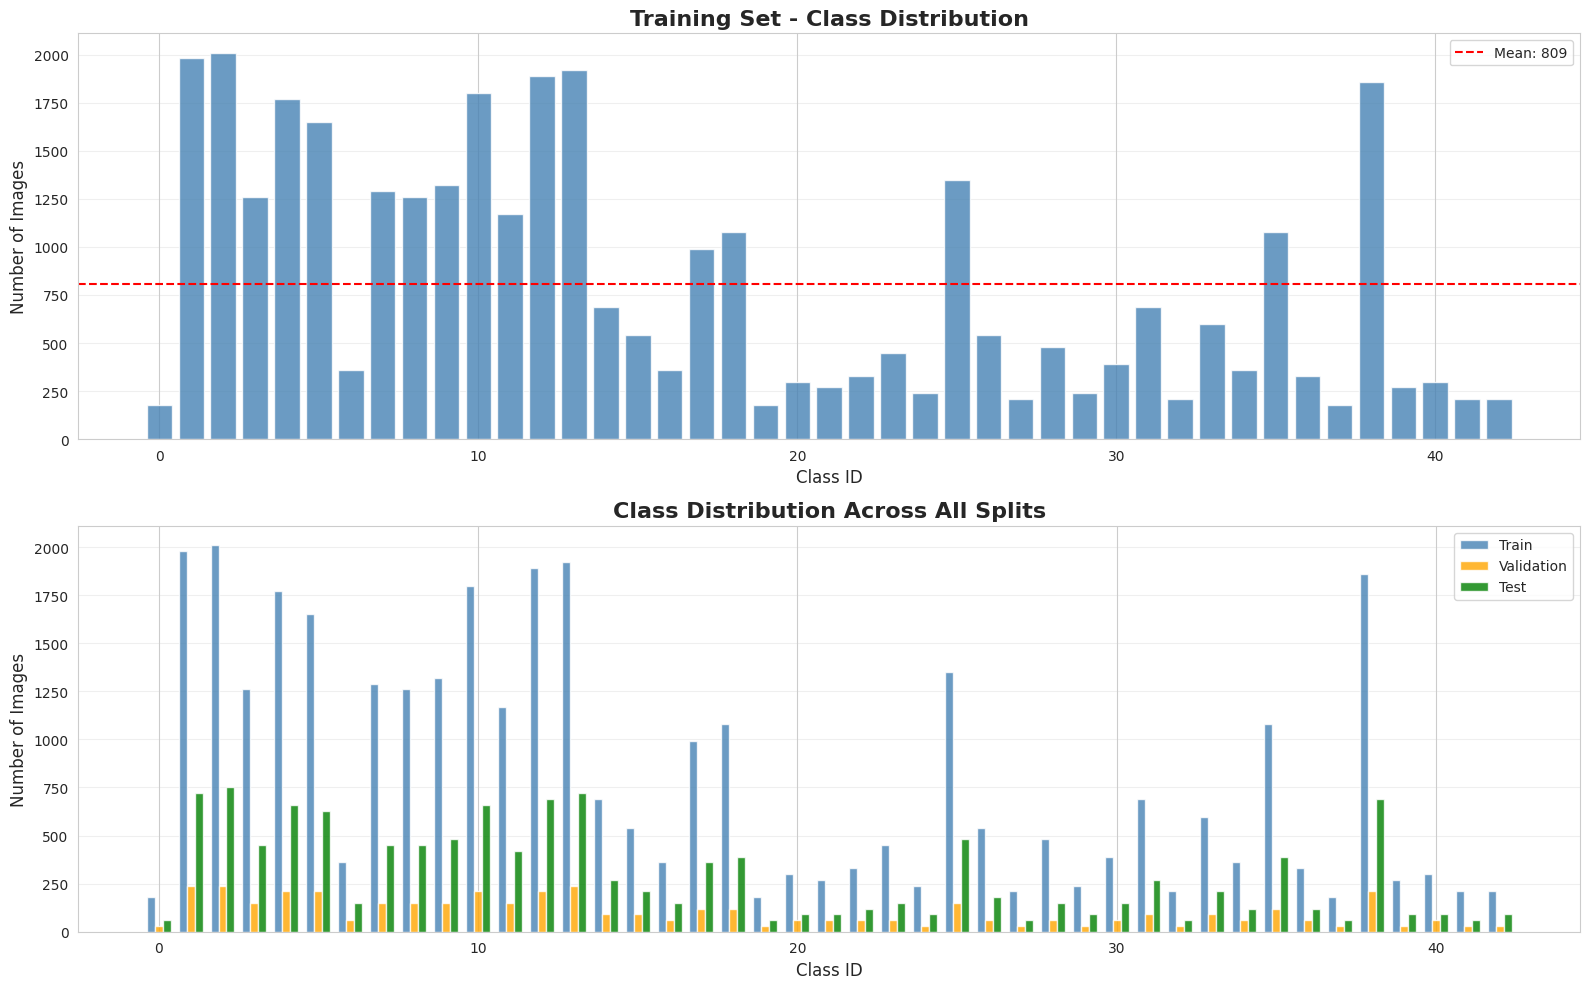


📊 Statistics:
   Min samples per class: 180 (Class 0)
   Max samples per class: 2010 (Class 2)
   Mean samples per class: 809.28
   Std samples per class: 626.75
   ⚠️ Class Imbalance Ratio: 11.17x


In [5]:
# Plot class distribution
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Training set distribution
axes[0].bar(class_dist['ClassId'], class_dist['Train'], color='steelblue', alpha=0.8)
axes[0].set_title('Training Set - Class Distribution', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Class ID', fontsize=12)
axes[0].set_ylabel('Number of Images', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)
axes[0].axhline(y=class_dist['Train'].mean(), color='red', linestyle='--', label=f'Mean: {class_dist["Train"].mean():.0f}')
axes[0].legend()

# All splits comparison
x = np.arange(len(class_dist))
width = 0.25
axes[1].bar(x - width, class_dist['Train'], width, label='Train', color='steelblue', alpha=0.8)
axes[1].bar(x, class_dist['Valid'], width, label='Validation', color='orange', alpha=0.8)
axes[1].bar(x + width, class_dist['Test'], width, label='Test', color='green', alpha=0.8)
axes[1].set_title('Class Distribution Across All Splits', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Class ID', fontsize=12)
axes[1].set_ylabel('Number of Images', fontsize=12)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../experiments/visualization/gtsrb_class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n📊 Statistics:")
print(f"   Min samples per class: {class_dist['Train'].min()} (Class {class_dist.loc[class_dist['Train'].idxmin(), 'ClassId']})")
print(f"   Max samples per class: {class_dist['Train'].max()} (Class {class_dist.loc[class_dist['Train'].idxmax(), 'ClassId']})")
print(f"   Mean samples per class: {class_dist['Train'].mean():.2f}")
print(f"   Std samples per class: {class_dist['Train'].std():.2f}")
print(f"   ⚠️ Class Imbalance Ratio: {class_dist['Train'].max() / class_dist['Train'].min():.2f}x")

## 6. Visualize Sample Images from Each Class

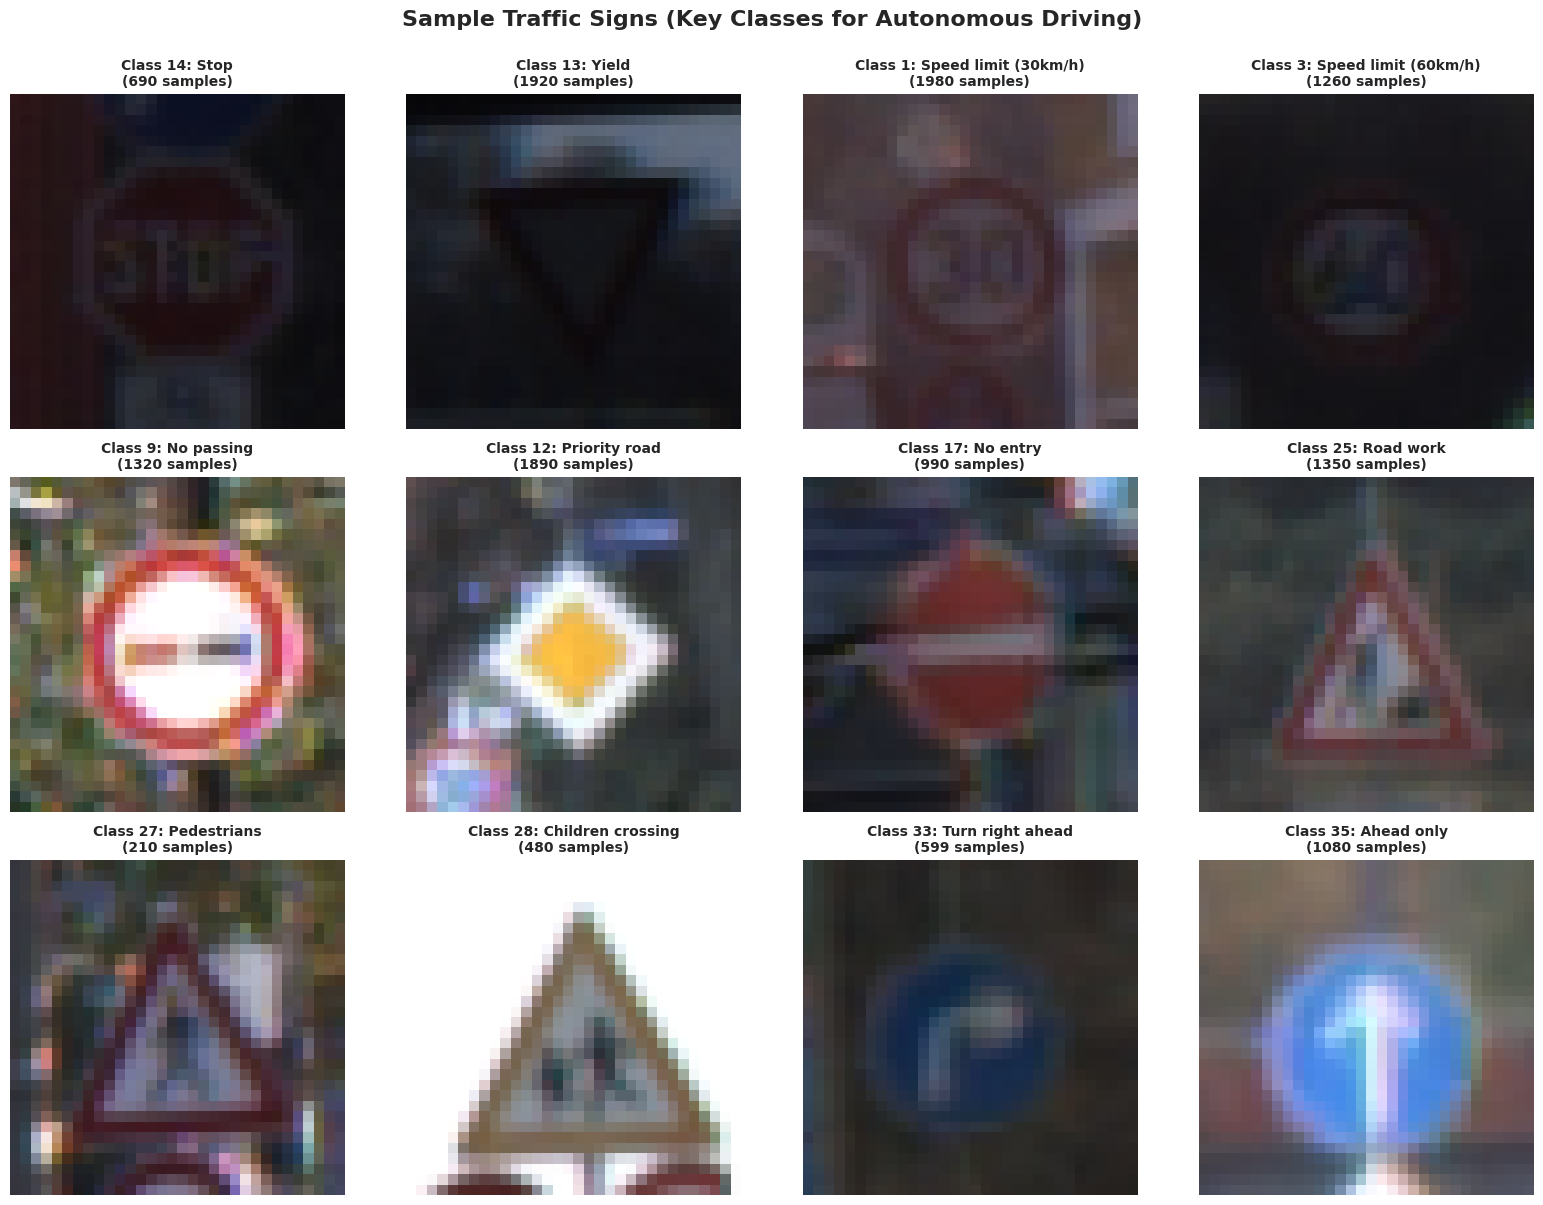

In [6]:
# Select representative classes (important for autonomous driving)
important_classes = [
    14,  # Stop sign
    13,  # Yield
    1,   # Speed limit 30km/h
    3,   # Speed limit 60km/h
    9,   # No passing
    12,  # Priority road
    17,  # No entry
    25,  # Road work
    27,  # Pedestrians
    28,  # Children crossing
    33,  # Turn right ahead
    35,  # Ahead only
]

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for idx, class_id in enumerate(important_classes):
    # Find first image of this class
    sample_idx = np.where(y_train == class_id)[0][0]
    sample_img = X_train[sample_idx]
    sign_name = sign_names[sign_names['ClassId'] == class_id]['SignName'].values[0]
    
    axes[idx].imshow(sample_img)
    axes[idx].set_title(f"Class {class_id}: {sign_name}\n({class_dist[class_dist['ClassId']==class_id]['Train'].values[0]} samples)", 
                       fontsize=10, fontweight='bold')
    axes[idx].axis('off')

plt.suptitle('Sample Traffic Signs (Key Classes for Autonomous Driving)', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('../experiments/visualization/gtsrb_sample_images.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Image Quality & Properties Analysis

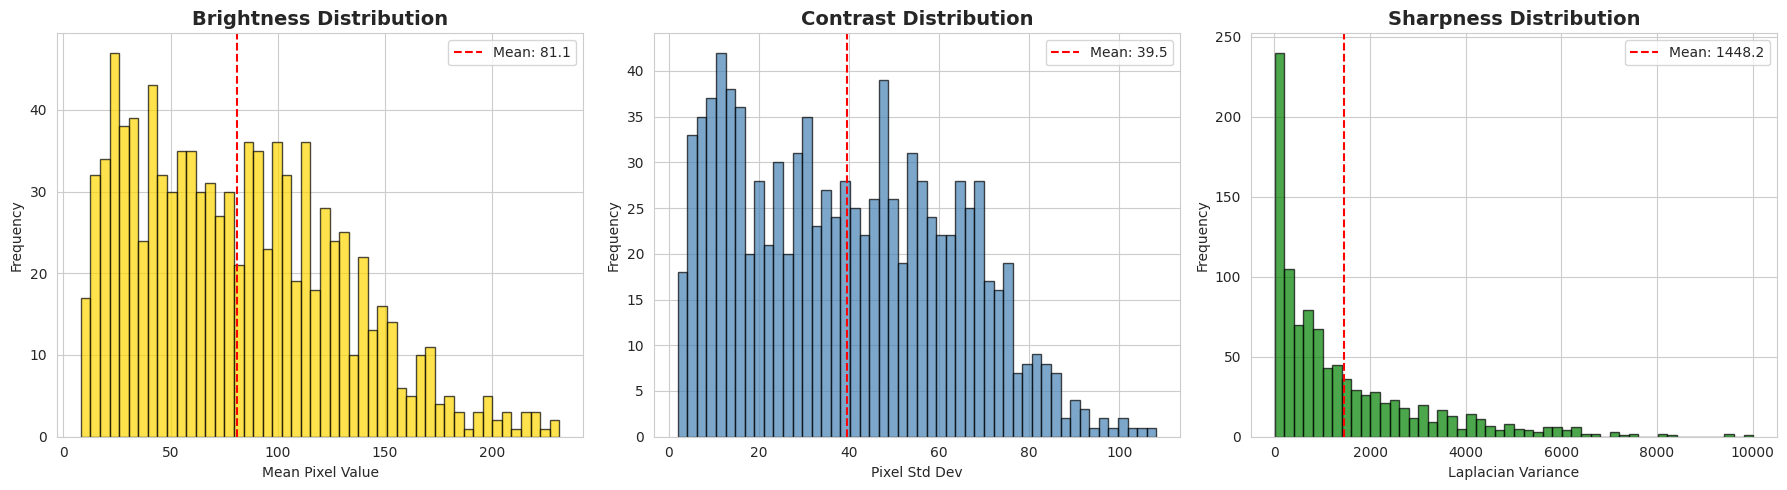


📊 Image Quality Metrics (n=1000):
   Brightness: 81.11 ± 47.49
   Contrast: 39.52 ± 23.55
   Sharpness: 1448.17 ± 1660.63


In [7]:
# Analyze image properties
sample_size = 1000  # Sample for speed
sample_indices = np.random.choice(len(X_train), sample_size, replace=False)

brightness = []
contrast = []
sharpness = []

for idx in sample_indices:
    img = X_train[idx]
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    
    # Brightness (mean pixel value)
    brightness.append(gray.mean())
    
    # Contrast (std of pixel values)
    contrast.append(gray.std())
    
    # Sharpness (Laplacian variance)
    laplacian = cv2.Laplacian(gray, cv2.CV_64F)
    sharpness.append(laplacian.var())

# Plot distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(brightness, bins=50, color='gold', alpha=0.7, edgecolor='black')
axes[0].set_title('Brightness Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Mean Pixel Value')
axes[0].set_ylabel('Frequency')
axes[0].axvline(np.mean(brightness), color='red', linestyle='--', label=f'Mean: {np.mean(brightness):.1f}')
axes[0].legend()

axes[1].hist(contrast, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[1].set_title('Contrast Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Pixel Std Dev')
axes[1].set_ylabel('Frequency')
axes[1].axvline(np.mean(contrast), color='red', linestyle='--', label=f'Mean: {np.mean(contrast):.1f}')
axes[1].legend()

axes[2].hist(sharpness, bins=50, color='green', alpha=0.7, edgecolor='black')
axes[2].set_title('Sharpness Distribution', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Laplacian Variance')
axes[2].set_ylabel('Frequency')
axes[2].axvline(np.mean(sharpness), color='red', linestyle='--', label=f'Mean: {np.mean(sharpness):.1f}')
axes[2].legend()

plt.tight_layout()
plt.savefig('../experiments/visualization/gtsrb_image_quality.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n📊 Image Quality Metrics (n={sample_size}):")
print(f"   Brightness: {np.mean(brightness):.2f} ± {np.std(brightness):.2f}")
print(f"   Contrast: {np.mean(contrast):.2f} ± {np.std(contrast):.2f}")
print(f"   Sharpness: {np.mean(sharpness):.2f} ± {np.std(sharpness):.2f}")

## 8. Key Classes for Road-Sense Project


  CRITICAL TRAFFIC SIGN CATEGORIES FOR AUTONOMOUS DRIVING
        Category  Classes  Training Samples Percentage
Regulatory Signs       13             16410     47.16%
   Warning Signs       14              6750     19.40%
 Mandatory Signs        8              4979     14.31%
  Priority Signs        4              5670     16.29%


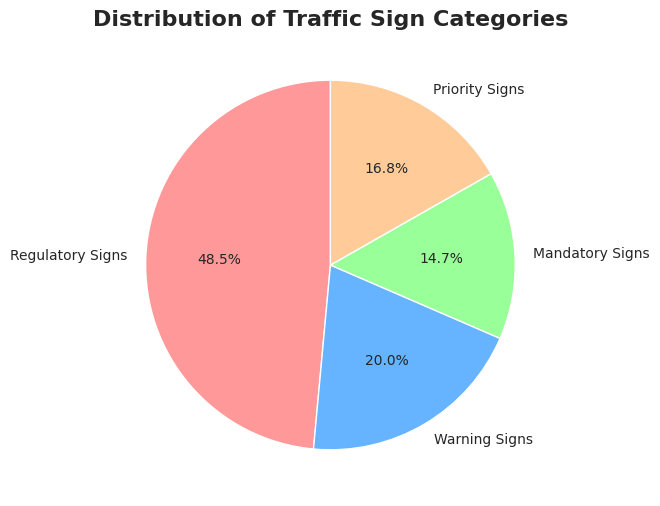

In [8]:
# Define critical classes for autonomous driving
critical_classes = {
    'Regulatory Signs': [0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 15, 16, 17],  # Speed limits, no passing, prohibitions
    'Warning Signs': [18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31],  # Caution, curves, pedestrians
    'Mandatory Signs': [33, 34, 35, 36, 37, 38, 39, 40],  # Turn directions, straight
    'Priority Signs': [11, 12, 13, 14],  # Yield, stop, priority
}

# Calculate samples for each category
category_stats = []
for category, class_ids in critical_classes.items():
    count = class_dist[class_dist['ClassId'].isin(class_ids)]['Train'].sum()
    category_stats.append({
        'Category': category,
        'Classes': len(class_ids),
        'Training Samples': count,
        'Percentage': f"{count/len(X_train)*100:.2f}%"
    })

category_df = pd.DataFrame(category_stats)

print("\n" + "="*70)
print("  CRITICAL TRAFFIC SIGN CATEGORIES FOR AUTONOMOUS DRIVING")
print("="*70)
print(category_df.to_string(index=False))
print("="*70)

# Visualize category distribution
plt.figure(figsize=(10, 6))
plt.pie(category_df['Training Samples'], labels=category_df['Category'], autopct='%1.1f%%', 
        startangle=90, colors=['#ff9999','#66b3ff','#99ff99','#ffcc99'])
plt.title('Distribution of Traffic Sign Categories', fontsize=16, fontweight='bold')
plt.savefig('../experiments/visualization/gtsrb_category_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Integration with KITTI Dataset

In [10]:
# Compare German-TS with KITTI
print("\n" + "="*70)
print("  DATASET COMPARISON: KITTI vs GERMAN TRAFFIC SIGNS")
print("="*70)

comparison = pd.DataFrame({
    'Aspect': [
        'Primary Objects',
        'Number of Classes',
        'Total Training Images',
        'Image Size',
        'Annotation Type',
        'Use Case',
        'Strengths',
        'Limitations'
    ],
    'KITTI': [
        'Vehicles, Pedestrians, Cyclists',
        '8 (using 3: Car, Pedestrian, Cyclist)',
        '7,481',
        'Variable (1224-1242 × 370-376)',
        '2D/3D Bounding Boxes',
        'Large object detection in driving scenes',
        'Real driving context, multiple objects',
        'No traffic signs, German roads only'
    ],
    'German Traffic Signs': [
        'Traffic Signs',
        '43',
        '34,799',
        'Fixed (32 × 32 × 3)',
        'Image Classification (full image)',
        'Traffic sign recognition',
        'Comprehensive sign coverage, large dataset',
        'Small images, no context, classification only'
    ]
})

print(comparison.to_string(index=False))
print("="*70)

print("\n💡 INTEGRATION STRATEGY:")
print("   1. KITTI: Train YOLO for vehicle/pedestrian/cyclist detection")
print("   2. German-TS: Add traffic sign detection capability")
print("   3. Both datasets complement each other perfectly!")
print("   4. Challenge: German-TS is classification (full image), not detection (bounding boxes)")


  DATASET COMPARISON: KITTI vs GERMAN TRAFFIC SIGNS
               Aspect                                    KITTI                          German Traffic Signs
      Primary Objects          Vehicles, Pedestrians, Cyclists                                 Traffic Signs
    Number of Classes    8 (using 3: Car, Pedestrian, Cyclist)                                            43
Total Training Images                                    7,481                                        34,799
           Image Size           Variable (1224-1242 × 370-376)                           Fixed (32 × 32 × 3)
      Annotation Type                     2D/3D Bounding Boxes             Image Classification (full image)
             Use Case Large object detection in driving scenes                      Traffic sign recognition
            Strengths   Real driving context, multiple objects    Comprehensive sign coverage, large dataset
          Limitations      No traffic signs, German roads only Small images

## 10. Recommendations for Road-Sense Project

In [11]:
print("\n" + "="*70)
print("  RECOMMENDATIONS FOR MULTI-DATASET TRAINING")
print("="*70)

recommendations = """
✅ RECOMMENDED APPROACH: TWO-STAGE TRAINING

STAGE 1: KITTI Fine-tuning (Weeks 2-3)
   • Fine-tune YOLOv8/v11 (pre-trained on COCO) on KITTI
   • Classes: Vehicle (Car+Van+Truck), Pedestrian, Cyclist
   • Output: Model detects vehicles and people in driving scenes
   • Dataset: 7,481 images with bounding boxes

STAGE 2: Traffic Sign Integration (Week 4)
   • Option A: Synthetic Data Generation
     - Place German-TS signs into KITTI images
     - Create bounding boxes for traffic signs
     - Augment KITTI with 5,000-10,000 synthetic images
   
   • Option B: Use Real Traffic Sign Detection Dataset
     - German Traffic Sign Detection Benchmark (GTSDB)
     - Has bounding boxes for signs in real driving scenes
     - ~900 images (smaller but real context)
   
   • Option C: Transfer Learning
     - Keep vehicle/pedestrian detector from Stage 1
     - Add separate classification head for signs
     - Multi-task learning architecture

FINAL MODEL:
   • Detects: Vehicles, Pedestrians, Cyclists, Traffic Signs
   • Classes: 4-6 (depending on sign grouping)
   • Trained on: KITTI (vehicles/people) + GTSDB or synthetic (signs)

⚠️ KEY CHALLENGE:
   German-TS (GTSRB) is for CLASSIFICATION (full image = 1 sign)
   We need DETECTION (find sign in scene + classify)
   → Need to use GTSDB or create synthetic detection dataset

📚 DATASETS TO CONSIDER:
   1. GTSDB (German Traffic Sign Detection Benchmark) - 900 images with bboxes
   2. Mapillary Vistas - Large-scale with traffic signs
   3. BDD100K - Berkeley driving dataset with signs
   4. Synthetic data generation from GTSRB
"""

print(recommendations)
print("="*70)


  RECOMMENDATIONS FOR MULTI-DATASET TRAINING

✅ RECOMMENDED APPROACH: TWO-STAGE TRAINING

STAGE 1: KITTI Fine-tuning (Weeks 2-3)
   • Fine-tune YOLOv8/v11 (pre-trained on COCO) on KITTI
   • Classes: Vehicle (Car+Van+Truck), Pedestrian, Cyclist
   • Output: Model detects vehicles and people in driving scenes
   • Dataset: 7,481 images with bounding boxes

STAGE 2: Traffic Sign Integration (Week 4)
   • Option A: Synthetic Data Generation
     - Place German-TS signs into KITTI images
     - Create bounding boxes for traffic signs
     - Augment KITTI with 5,000-10,000 synthetic images
   
   • Option B: Use Real Traffic Sign Detection Dataset
     - German Traffic Sign Detection Benchmark (GTSDB)
     - Has bounding boxes for signs in real driving scenes
     - ~900 images (smaller but real context)
   
   • Option C: Transfer Learning
     - Keep vehicle/pedestrian detector from Stage 1
     - Add separate classification head for signs
     - Multi-task learning architecture

FINAL M

## 11. Export Statistics

In [ ]:
# Save class distribution to CSV
class_dist_export = class_dist[['ClassId', 'SignName', 'Train', 'Valid', 'Test', 'Total', 'Train_Pct']]
class_dist_export.to_csv('../experiments/visualization/gtsrb_class_distribution.csv', index=False)

print("✅ Exported class distribution to: experiments/visualization/gtsrb_class_distribution.csv")

# Create summary statistics
summary = {
    'Metric': [
        'Total Training Images',
        'Total Validation Images',
        'Total Test Images',
        'Number of Classes',
        'Image Size',
        'Min Samples per Class',
        'Max Samples per Class',
        'Mean Samples per Class',
        'Class Imbalance Ratio',
    ],
    'Value': [
        f"{len(X_train):,}",
        f"{len(X_valid):,}",
        f"{len(X_test):,}",
        f"{len(sign_names)}",
        f"{X_train[0].shape}",
        f"{class_dist['Train'].min()}",
        f"{class_dist['Train'].max()}",
        f"{class_dist['Train'].mean():.2f}",
        f"{class_dist['Train'].max() / class_dist['Train'].min():.2f}x",
    ]
}

summary_df = pd.DataFrame(summary)
summary_df.to_csv('../experiments/visualization/gtsrb_summary_statistics.csv', index=False)

print("✅ Exported summary statistics to: experiments/visualization/gtsrb_summary_statistics.csv")

print("\n" + "="*70)
print("  ANALYSIS COMPLETE! 🎉")
print("="*70)
print("\n📊 Generated visualizations:")
print("   • gtsrb_class_distribution.png")
print("   • gtsrb_sample_images.png")
print("   • gtsrb_image_quality.png")
print("   • gtsrb_category_distribution.png")
print("\n📄 Generated reports:")
print("   • gtsrb_class_distribution.csv")
print("   • gtsrb_summary_statistics.csv")
print("\n➡️  Next Steps:")
print("   1. Review the training strategy recommendations above")
print("   2. Decide on traffic sign integration approach")
print("   3. Update preprocessing config for multi-dataset training")
print("   4. Consider downloading GTSDB for detection (not just classification)")

In [ ]:
# Save class distribution to CSV
class_dist_export = class_dist[['ClassId', 'SignName', 'Train', 'Valid', 'Test', 'Total', 'Train_Pct']]
class_dist_export.to_csv('../experiments/visualization/gtsrb_class_distribution.csv', index=False)

print("✅ Exported class distribution to: experiments/visualization/gtsrb_class_distribution.csv")

# Create summary statistics
summary = {
    'Metric': [
        'Total Training Images',
        'Total Validation Images',
        'Total Test Images',
        'Number of Classes',
        'Image Size',
        'Min Samples per Class',
        'Max Samples per Class',
        'Mean Samples per Class',
        'Class Imbalance Ratio',
    ],
    'Value': [
        f"{len(X_train):,}",
        f"{len(X_valid):,}",
        f"{len(X_test):,}",
        f"{len(sign_names)}",
        f"{X_train[0].shape}",
        f"{class_dist['Train'].min()}",
        f"{class_dist['Train'].max()}",
        f"{class_dist['Train'].mean():.2f}",
        f"{class_dist['Train'].max() / class_dist['Train'].min():.2f}x",
    ]
}

summary_df = pd.DataFrame(summary)
summary_df.to_csv('../experiments/visualization/gtsrb_summary_statistics.csv', index=False)

print("✅ Exported summary statistics to: experiments/visualization/gtsrb_summary_statistics.csv")

print("\n" + "="*70)
print("  ANALYSIS COMPLETE! 🎉")
print("="*70)
print("\n📊 Generated visualizations:")
print("   • gtsrb_class_distribution.png")
print("   • gtsrb_sample_images.png")
print("   • gtsrb_image_quality.png")
print("   • gtsrb_category_distribution.png")
print("\n📄 Generated reports:")
print("   • gtsrb_class_distribution.csv")
print("   • gtsrb_summary_statistics.csv")
print("\n➡️  Next Steps:")
print("   1. Review the training strategy recommendations above")
print("   2. Decide on traffic sign integration approach")
print("   3. Update preprocessing config for multi-dataset training")
print("   4. Consider downloading GTSDB for detection (not just classification)")